In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.listdir('/content/drive/MyDrive/anemia_detection/datasets')

['palpablepalm_dataset.zip',
 'fingernails_dataset.zip',
 'conjunctiva_dataset.zip']

In [3]:
!unzip "/content/drive/MyDrive/anemia_detection/datasets/conjunctiva_dataset.zip"


Archive:  /content/drive/MyDrive/anemia_detection/datasets/conjunctiva_dataset.zip
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (6).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (2).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (3).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (4).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (5).png  
  inflating: Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-001 (7).png  
  inflating: Application of Machine Learn

In [4]:
import os

os.listdir('/content')
dataset_path = "/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana"
from glob import glob

images = glob(dataset_path + "/*.png")

print("Toplam görüntü:", len(images))
print(images[:5])

Toplam görüntü: 4262
['/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-036 (2).png', '/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-Conj-006 (2).png', '/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-136 (5).png', '/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Non-Anemic-168 (11).png', '/content/Application of Machine Learning in Detecting Iron Deficiency Anemia Using  Conjunctiva image Dataset from Ghana/Anemic-028 (4).png']


In [5]:
import os
from glob import glob

images = glob(dataset_path + "/*")

print("Toplam bulunan dosya:", len(images))
for x in images[:10]:
    print(repr(os.path.basename(x)))

Toplam bulunan dosya: 4262
'Anemic-036 (2).png'
'Anemic-Conj-006 (2).png'
'Anemic-136 (5).png'
'Non-Anemic-168 (11).png'
'Anemic-028 (4).png'
'Anemic-258 (5).png'
'Anemic-081 (6).png'
'Anemic-Conj-031 (3).png'
'Non-Anemic-014 (6).png'
'Anemic-016 (6).png'


In [6]:
import os
import re
import pandas as pd
from glob import glob

files = glob(os.path.join(dataset_path, "*.png"))

def parse_filename(path):
    name = os.path.basename(path)
    stem = os.path.splitext(name)[0]

    # augmentation numarası
    aug_match = re.search(r"\((\d+)\)$", stem)
    if aug_match:
        aug_no = int(aug_match.group(1))
        stem_core = re.sub(r"\s*\(\d+\)$", "", stem)
    else:
        aug_no = 1
        stem_core = stem

    lower = stem_core.lower()

    # sınıf
    if lower.startswith("non-anemic"):
        cls = "Non-Anemic"
        rest = stem_core[len("Non-Anemic-"):] if stem_core.startswith("Non-Anemic-") else stem_core[len("Non-anemic-"):]
    elif lower.startswith("anemic"):
        cls = "Anemic"
        rest = stem_core[len("Anemic-"):]
    else:
        cls = "Unknown"
        rest = stem_core

    # subtype
    subtype = "base"
    if rest.endswith("FV"):
        subtype = "FV"
        rest = rest[:-2]
    elif rest.endswith("RA"):
        subtype = "RA"
        rest = rest[:-2]
    elif "Conj-" in rest:
        subtype = "Conj"
        rest = rest.replace("Conj-", "")
    elif "Con-" in rest:
        subtype = "Con"
        rest = rest.replace("Con-", "")

    # id yakala
    id_match = re.search(r"(\d+)", rest)
    sample_id = id_match.group(1) if id_match else None

    series_key = f"{cls}_{sample_id}_{subtype}"

    return {
        "filename": name,
        "class": cls,
        "sample_id": sample_id,
        "subtype": subtype,
        "aug_no": aug_no,
        "series_key": series_key,
        "path": path
    }

df = pd.DataFrame([parse_filename(f) for f in files])

print(df.head(20))
print("\nSubtype sayıları:")
print(df["subtype"].value_counts())

print("\nSeri sayıları:")
print(df["series_key"].nunique())

print("\nHer seride kaç görüntü var:")
print(df.groupby("series_key").size().value_counts().sort_index())

                   filename       class sample_id subtype  aug_no  \
0        Anemic-036 (2).png      Anemic       036    base       2   
1   Anemic-Conj-006 (2).png      Anemic       006    Conj       2   
2        Anemic-136 (5).png      Anemic       136    base       5   
3   Non-Anemic-168 (11).png  Non-Anemic       168    base      11   
4        Anemic-028 (4).png      Anemic       028    base       4   
5        Anemic-258 (5).png      Anemic       258    base       5   
6        Anemic-081 (6).png      Anemic       081    base       6   
7   Anemic-Conj-031 (3).png      Anemic       031    Conj       3   
8    Non-Anemic-014 (6).png  Non-Anemic       014    base       6   
9        Anemic-016 (6).png      Anemic       016    base       6   
10  Non-Anemic-184 (11).png  Non-Anemic       184    base      11   
11   Non-Anemic-129 (2).png  Non-Anemic       129    base       2   
12       Anemic-123 (6).png      Anemic       123    base       6   
13       Non-Anemic-084.png  Non-A

In [7]:
anemic_count = df["filename"].str.startswith("Anemic").sum()
non_anemic_count = (
    df["filename"].str.startswith("Non-Anemic").sum()
    + df["filename"].str.startswith("Non-anemic").sum()
)

print("Anemic ile başlayan:", anemic_count)
print("Non-anemic ile başlayan:", non_anemic_count)
print("Toplam:", anemic_count + non_anemic_count)

Anemic ile başlayan: 2558
Non-anemic ile başlayan: 1704
Toplam: 4262


In [8]:
import cv2
import numpy as np

# Tüm veriyi kullan
df_exp = df.copy()

print("Kullanılan veri sayısı:", len(df_exp))
print(df_exp["subtype"].value_counts())
print(df_exp["class"].value_counts())

groups = []
features = []
labels = []

for _, row in df_exp.iterrows():
    img = cv2.imread(row["path"])
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    H, S, V = cv2.split(hsv)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    L, a, b = cv2.split(lab)

    R_mean = np.mean(R)
    G_mean = np.mean(G)
    B_mean = np.mean(B)

    features.append([
        # RGB mean/std
        np.mean(R), np.std(R),
        np.mean(G), np.std(G),
        np.mean(B), np.std(B),

        # LAB mean/std
        np.mean(L), np.std(L),
        np.mean(a), np.std(a),
        np.mean(b), np.std(b),

        # HSV mean/std
        np.mean(H), np.std(H),
        np.mean(S), np.std(S),
        np.mean(V), np.std(V),

        # Percentiles
        np.percentile(R, 25), np.percentile(R, 50), np.percentile(R, 75),
        np.percentile(G, 25), np.percentile(G, 50), np.percentile(G, 75),
        np.percentile(B, 25), np.percentile(B, 50), np.percentile(B, 75),

        # Color ratios
        R_mean / (G_mean + 1e-6),
        R_mean / (B_mean + 1e-6),
        G_mean / (B_mean + 1e-6),
        R_mean / (R_mean + G_mean + B_mean + 1e-6),
        G_mean / (R_mean + G_mean + B_mean + 1e-6),
        B_mean / (R_mean + G_mean + B_mean + 1e-6),

        # Gray texture basics
        np.mean(gray),
        np.std(gray),
        np.var(gray)
    ])

    labels.append(1 if row["class"] == "Anemic" else 0)
    groups.append(row["series_key"])

X = np.array(features, dtype=np.float32)
y = np.array(labels, dtype=np.int32)
groups = np.array(groups)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sınıf dağılımı:", np.bincount(y))
print("İlk 5 feature:\n", X[:10])
print("İlk 5 label:\n", y[:10])

Kullanılan veri sayısı: 4262
subtype
base    3808
Con      224
Conj     206
RA        12
FV        12
Name: count, dtype: int64
class
Anemic        2558
Non-Anemic    1704
Name: count, dtype: int64
X shape: (4262, 36)
y shape: (4262,)
Sınıf dağılımı: [1704 2558]
İlk 5 feature:
 [[5.3301071e+01 9.0825600e+01 4.3125591e+01 7.4969673e+01 4.3043697e+01
  7.5426270e+01 4.7435677e+01 8.1508636e+01 1.3180214e+02 7.5502472e+00
  1.2957295e+02 3.9929736e+00 2.2638197e+01 5.7652920e+01 1.4058136e+01
  2.8054892e+01 5.3304127e+01 9.0832146e+01 0.0000000e+00 0.0000000e+00
  1.6100000e+02 0.0000000e+00 0.0000000e+00 1.0200000e+02 0.0000000e+00
  0.0000000e+00 9.7750000e+01 1.2359499e+00 1.2383014e+00 1.0019026e+00
  3.8216773e-01 3.0920973e-01 3.0862254e-01 4.6158901e+01 7.9554642e+01
  6.3289409e+03]
 [3.7162331e+01 7.1280960e+01 3.0814487e+01 5.9486835e+01 3.4092495e+01
  6.5986122e+01 3.4333912e+01 6.6067978e+01 1.3097896e+02 5.8447676e+00
  1.2719869e+02 2.3839474e+00 3.4571686e+01 6.6454102e+0

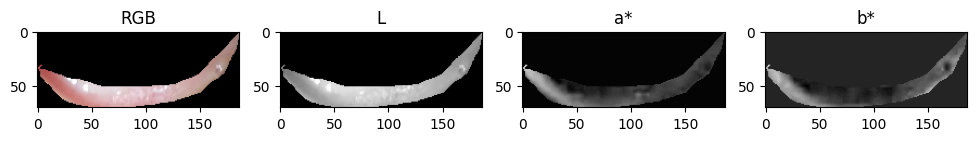

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

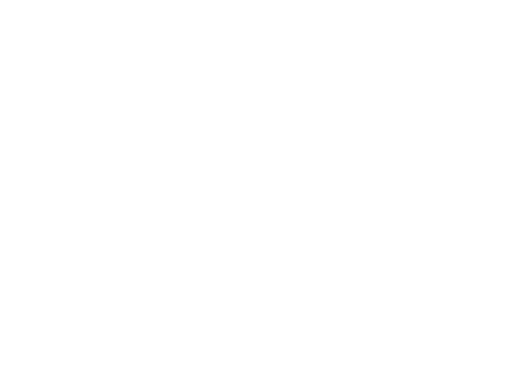

In [9]:
import matplotlib.pyplot as plt

row = df_exp.iloc[0]

img = cv2.imread(row["path"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

L,a,b = cv2.split(lab)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("RGB")

plt.subplot(1,4,2)
plt.imshow(L,cmap="gray")
plt.title("L")

plt.subplot(1,4,3)
plt.imshow(a,cmap="gray")
plt.title("a*")

plt.subplot(1,4,4)
plt.imshow(b,cmap="gray")
plt.title("b*")

plt.show()
plt.axis("off")

In [10]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3366, 36)
Test: (896, 36)


In [11]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(
    kernel="rbf",
    C=100,
    gamma="scale",
    probability=True,
    random_state=42
),
    "k-NN": KNeighborsClassifier(
        n_neighbors=150,
        weights="uniform",
        algorithm="auto",
        leaf_size=60,
        p=2,
        metric="chebyshev",
   ),
    "Decision Tree": DecisionTreeClassifier(
       criterion='gini',       # veya 'entropy' – bilgi kazancına göre bölme
       max_depth=15,         # Ağacın maksimum derinliği, overfitting’i engellemek için sınır koyabilirsin
       min_samples_split=8,    # Dallanmak için gereken minimum örnek sayısı
       min_samples_leaf=2,     # Yaprakta bulunacak minimum örnek sayısı
       max_features='log2',      # Bölmede kullanılacak maksimum özellik sayısı
       random_state=42
),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=350,
        learning_rate=0.5,
        max_depth=3,
        min_samples_split=2,
        min_samples_leaf=1,
        subsample=0.8,
        max_features="sqrt",
        random_state=42
    ),
  "XGBoost": XGBClassifier(
        n_estimators=1000,
        max_depth=3,
        subsample=1,
        colsample_bytree=0.95,
        reg_lambda=10,
        eval_metric="logloss",
        random_state=42
),

  "CatBoost": CatBoostClassifier(
    iterations=1000,           # Kaç ağaç oluşturulacağı, default 100
    learning_rate=0.5,        # Öğrenme hızı, küçük değer → daha stabil sonuç
    depth=6,                   # Ağaç derinliği, default 6
    l2_leaf_reg=3,             # L2 regularization katsayısı
    subsample=0.8,             # Rastgele örnekleme oranı
    colsample_bylevel=0.8,     # Özellik örnekleme oranı
    verbose=0,
    random_state=42
),

  "AdaBoost": AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, min_samples_leaf=2),      # Temel öğrenici, default DecisionTreeClassifier(max_depth=1)
    n_estimators=1000,          # Kaç ağaç/estimator oluşturulacağı, default 50
    learning_rate=1,        # Her estimator’un katkı ağırlığı, default 1.0
    random_state=42
),

    "HistGradientBoosting": HistGradientBoostingClassifier(
    max_iter=100,            # Kaç boosting iterasyonu yapılacağı, default 100
    learning_rate=0.5,       # Öğrenme hızı
    max_depth=None,           # Her ağaç için maksimum derinlik, None → tam büyüme
    min_samples_leaf=20,      # Yaprak başına minimum örnek sayısı
    max_leaf_nodes=31,        # Her ağacın maksimum yaprak sayısı
    l2_regularization=0.0,    # L2 regularizasyon katsayısı
    random_state=42
)
}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())


Naive Bayes
10-fold Group CV mean: 0.5841265057447282
std: 0.07594814850420119

SVM
10-fold Group CV mean: 0.561581338914402
std: 0.05960577674327531

k-NN
10-fold Group CV mean: 0.5559089998128577
std: 0.05054249094430201

Decision Tree
10-fold Group CV mean: 0.6340610393895348
std: 0.09359980607707301

Gradient Boosting
10-fold Group CV mean: 0.7060761976782253
std: 0.09470009987258725

XGBoost
10-fold Group CV mean: 0.7050264703493592
std: 0.08167570913179253

CatBoost
10-fold Group CV mean: 0.7019994292254588
std: 0.0791475571962836

AdaBoost
10-fold Group CV mean: 0.6795938382070226
std: 0.06762193453981735

HistGradientBoosting
10-fold Group CV mean: 0.7214431590647832
std: 0.06878311854706133


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
     "Naive Bayes": GaussianNB(var_smoothing=1e-3),

}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())


Naive Bayes
10-fold Group CV mean: 0.5926615868258415
std: 0.05756073065882558


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "SVM": SVC(
    kernel="rbf",
    C=100,
    gamma="scale",
    probability=True,
    random_state=42
),

}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())


SVM
10-fold Group CV mean: 0.561581338914402
std: 0.05960577674327531


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "k-NN": KNeighborsClassifier(
        n_neighbors=150,
        weights="uniform",
        algorithm="auto",
        leaf_size=60,
        p=2,
        metric="chebyshev",
   ),

}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())


k-NN
10-fold Group CV mean: 0.5547899521938102
std: 0.05057102654719316


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(
       criterion='gini',       # veya 'entropy' – bilgi kazancına göre bölme
       max_depth=15,         # Ağacın maksimum derinliği, overfitting’i engellemek için sınır koyabilirsin
       min_samples_split=8,    # Dallanmak için gereken minimum örnek sayısı
       min_samples_leaf=2,     # Yaprakta bulunacak minimum örnek sayısı
       max_features='log2',      # Bölmede kullanılacak maksimum özellik sayısı
       random_state=42
),

}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())


Decision Tree
10-fold Group CV mean: 0.6340610393895348
std: 0.09359980607707301


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=350,
        learning_rate=0.5,
        max_depth=3,
        min_samples_split=2,
        min_samples_leaf=1,
        subsample=0.8,
        max_features="sqrt",
        random_state=42
    )

}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())


Gradient Boosting
10-fold Group CV mean: 0.7141422589658319
std: 0.08089215838919547


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "XGBoost": XGBClassifier(
        n_estimators=1000,
        max_depth=3,
        subsample=1,
        colsample_bytree=0.95,
        reg_lambda=10,
        eval_metric="logloss",
        random_state=42
),
}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())


XGBoost
10-fold Group CV mean: 0.7050264703493592
std: 0.08167570913179253


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "CatBoost": CatBoostClassifier(
    iterations=1000,           # Kaç ağaç oluşturulacağı, default 100
    learning_rate=0.5,        # Öğrenme hızı, küçük değer → daha stabil sonuç
    depth=6,                   # Ağaç derinliği, default 6
    l2_leaf_reg=3,             # L2 regularization katsayısı
    subsample=0.8,             # Rastgele örnekleme oranı
    colsample_bylevel=0.8,     # Özellik örnekleme oranı
    verbose=0,
    random_state=42
),
}
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        groups=groups_train,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("10-fold Group CV mean:", scores.mean())
    print("std:", scores.std())

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # bazı modellerde predict_proba olmayabilir
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = roc_auc_score(y_test, y_pred)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Algorithm": name,
        "Accuracy": round(acc*100,4),
        "F1-score": round(f1*100,4),
        "AUC": round(auc*100,4),
        "Precision": round(prec*100,4),
        "Recall": round(rec*100,4)
    })

results_df = pd.DataFrame(results)

results_df

,Algorithm,Accuracy,F1-score,AUC,Precision,Recall
0,Naive Bayes,64.1741,72.5875,63.0431,70.1320,75.2212
1,SVM,67.0759,78.3883,58.9242,66.8750,94.6903
2,k-NN,63.1696,74.4977,58.1114,66.1180,85.3097
3,Decision Tree,67.5223,72.0997,66.4118,78.6611,66.5487
4,Gradient Boosting,62.9464,71.0801,68.6287,69.9828,72.2124
5,XGBoost,66.4062,72.5114,65.7755,74.9057,70.2655
6,CatBoost,61.7188,70.1480,66.1391,69.0068,71.3274
7,AdaBoost,61.7188,68.1523,66.1150,71.6797,64.9558
8,HistGradientBoosting,58.8170,66.0534,66.5551,68.7739,63.5398


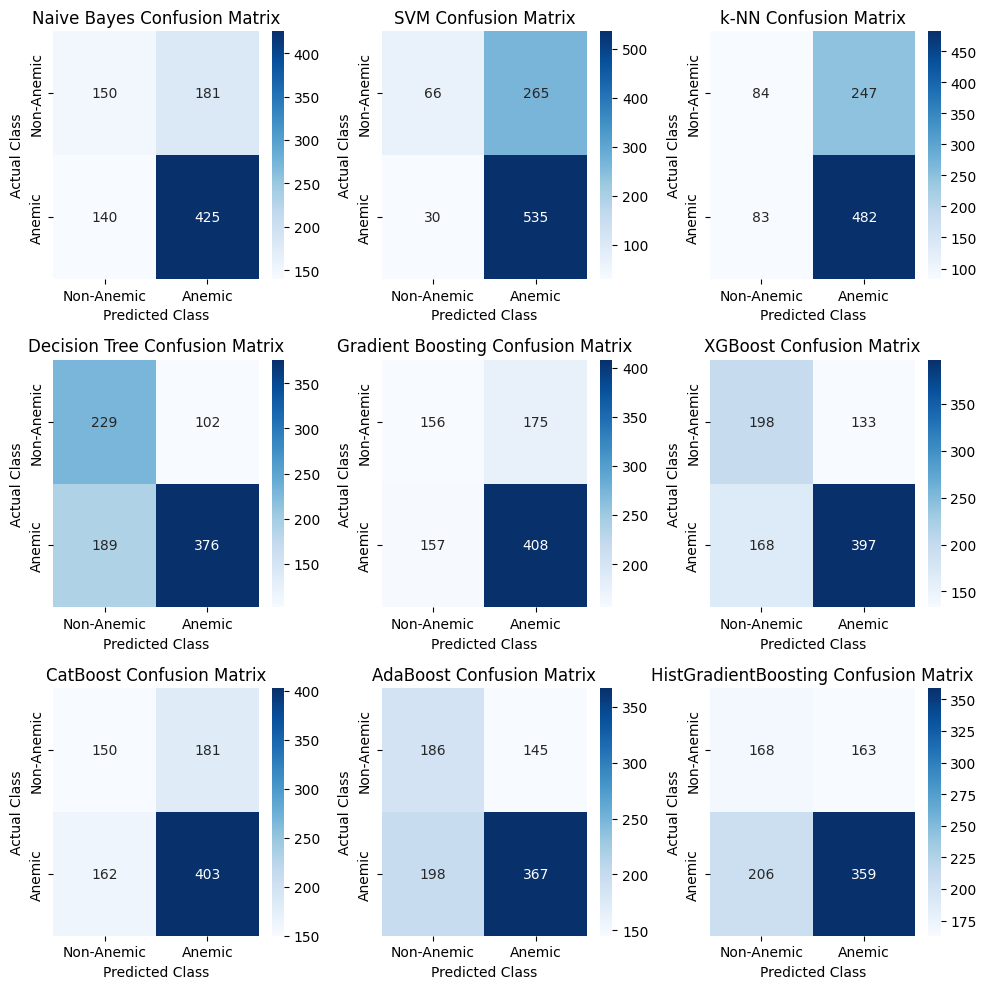

In [14]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3,3, figsize=(10,10))

axes = axes.flatten()

for i, (name,model) in enumerate(models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test,y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=["Non-Anemic","Anemic"],
        yticklabels=["Non-Anemic","Anemic"]
    )

    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel("Predicted Class")
    axes[i].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

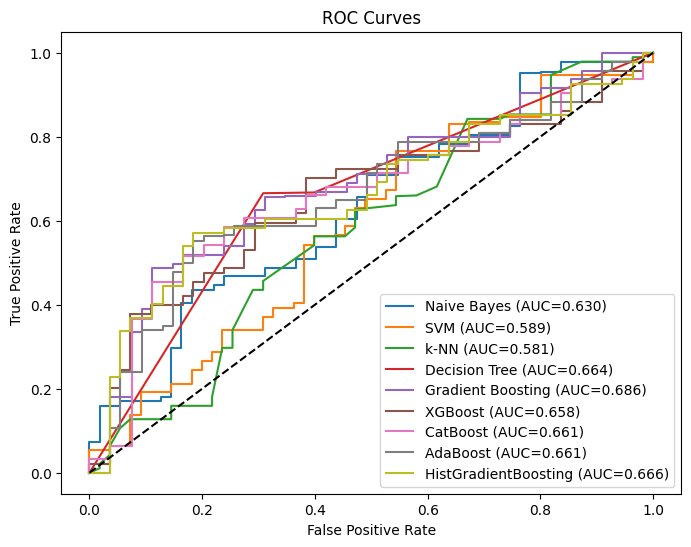

In [15]:

from sklearn.metrics import roc_curve, auc as sk_auc

plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:
        probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = sk_auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [ ]:
import joblib
import os

# Kaydedilecek klasör
model_folder = "conjunctiva_models"
os.makedirs(model_folder, exist_ok=True)

for name, model in models.items():
    # Modeli dosyaya kaydet
    filename = os.path.join(model_folder, f"{name.replace(' ','_')}.joblib")
    joblib.dump(model, filename)
    print(f"{name} kaydedildi → {filename}")

Naive Bayes kaydedildi → conjunctiva_models/Naive_Bayes.joblib
SVM kaydedildi → conjunctiva_models/SVM.joblib
k-NN kaydedildi → conjunctiva_models/k-NN.joblib
Decision Tree kaydedildi → conjunctiva_models/Decision_Tree.joblib
Gradient Boosting kaydedildi → conjunctiva_models/Gradient_Boosting.joblib
XGBoost kaydedildi → conjunctiva_models/XGBoost.joblib
CatBoost kaydedildi → conjunctiva_models/CatBoost.joblib
AdaBoost kaydedildi → conjunctiva_models/AdaBoost.joblib
HistGradientBoosting kaydedildi → conjunctiva_models/HistGradientBoosting.joblib



LightGBM
10-fold Group CV mean accuracy: 0.6948214966634454
10-fold Group CV std: 0.07778110195503016
  Algorithm  Accuracy  F1-score      AUC  Precision   Recall
0  LightGBM   61.6071   69.0647  67.1689    70.2011  67.9646


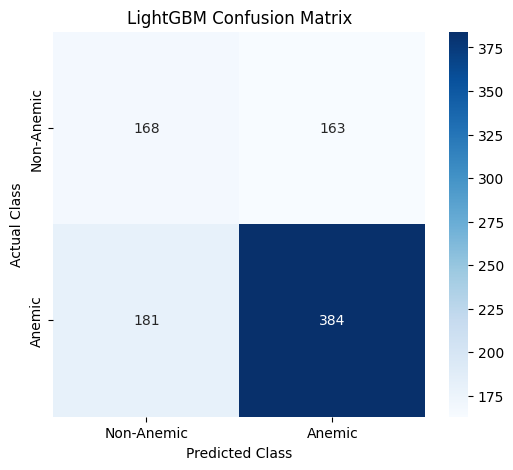

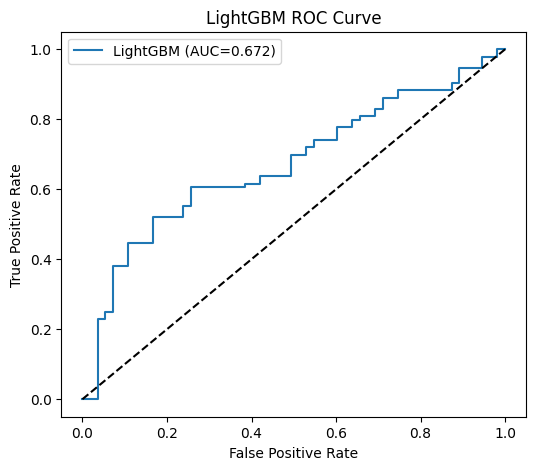

In [16]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc as sk_auc
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------
# LightGBM için dataframe (FULL FEATURE SET)
# -----------------------------------
feature_names = [
    # RGB
    "R_mean","R_std","G_mean","G_std","B_mean","B_std",

    # LAB
    "L_mean","L_std","a_mean","a_std","b_mean","b_std",

    # HSV
    "H_mean","H_std","S_mean","S_std","V_mean","V_std",

    # Percentiles RGB
    "R_p25","R_p50","R_p75",
    "G_p25","G_p50","G_p75",
    "B_p25","B_p50","B_p75",

    # Ratios
    "R_G","R_B","G_B",
    "R_ratio","G_ratio","B_ratio",

    # Gray texture
    "gray_mean","gray_std","gray_var"
]

X_train_lgb = pd.DataFrame(X_train, columns=feature_names)
X_test_lgb = pd.DataFrame(X_test, columns=feature_names)

# -----------------------------------
# LightGBM modeli
# -----------------------------------
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42,
    verbose=-1
)

# -----------------------------------
# GROUP BASED CROSS VALIDATION
# -----------------------------------
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(
    lgb_model,
    X_train_lgb,
    y_train,
    cv=cv,
    groups=groups_train,
    scoring="accuracy"
)

print("\nLightGBM")
print("10-fold Group CV mean accuracy:", scores.mean())
print("10-fold Group CV std:", scores.std())

# -----------------------------------
# TRAIN
# -----------------------------------
lgb_model.fit(X_train_lgb, y_train)

# -----------------------------------
# TEST
# -----------------------------------
y_pred_lgb = lgb_model.predict(X_test_lgb)
y_prob_lgb = lgb_model.predict_proba(X_test_lgb)[:, 1]

# -----------------------------------
# METRICS
# -----------------------------------
acc = accuracy_score(y_test, y_pred_lgb)
prec = precision_score(y_test, y_pred_lgb)
rec = recall_score(y_test, y_pred_lgb)
f1 = f1_score(y_test, y_pred_lgb)
auc = roc_auc_score(y_test, y_prob_lgb)

results_lgb = pd.DataFrame([{
    "Algorithm": "LightGBM",
    "Accuracy": round(acc * 100, 4),
    "F1-score": round(f1 * 100, 4),
    "AUC": round(auc * 100, 4),
    "Precision": round(prec * 100, 4),
    "Recall": round(rec * 100, 4)
}])

print(results_lgb)

# -----------------------------------
# CONFUSION MATRIX
# -----------------------------------
cm = confusion_matrix(y_test, y_pred_lgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Anemic", "Anemic"],
    yticklabels=["Non-Anemic", "Anemic"]
)

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

# -----------------------------------
# ROC CURVE
# -----------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob_lgb)
roc_auc = sk_auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"LightGBM (AUC={roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM ROC Curve")
plt.legend()

plt.show()

In [ ]:
import joblib
import os

# Kaydedilecek klasör
model_folder = "conjunctiva_models"

# LightGBM modelini kaydet
filename = os.path.join(model_folder, "LightGBM_model.joblib")
joblib.dump(lgb_model, filename)
print(f"LightGBM modeli kaydedildi → {filename}")

LightGBM modeli kaydedildi → conjunctiva_models/LightGBM_model.joblib
